In [ ]:
# 导入必要库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency
sns.set(style='whitegrid')
DATA_PATH = 'cardio_train.csv'
OUT_DIR = Path('graph')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [39]:
# 读取数据（分号分隔）
df = pd.read_csv(DATA_PATH, sep=';')

# 添加一列BMI
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

# 将年龄从天转换为年
df['age_years'] = (df['age'] / 365).astype(int)
df.drop(columns=['age'], inplace=True)

# 删掉身高小于120cm或大于220cm的
height_outlier_indices = df.index[(df['height'] < 120) | (df['height'] > 220)]
df.drop(index=height_outlier_indices, inplace=True)

# 删掉体重小于40kg或大于200kg的
weight_outlier_indices = df.index[(df['weight'] < 40) | (df['weight'] > 200)]
df.drop(index=weight_outlier_indices, inplace=True)

# 删掉不合理的BMI数值，标准如下
# 1为女性，2为男性；女性的BMI mean=24.5 sd=4.6, 男性的BMI mean=25.0 sd=4.6，3个SD之外的值视为异常
bmi_conditions = [
    (df['gender'] == 1) & ((df['bmi'] < (24.5 - 3 * 4.6)) | (df['bmi'] > (24.5 + 3 * 4.6))),
    (df['gender'] == 2) & ((df['bmi'] < (25.0 - 3 * 4.6)) | (df['bmi'] > (25.0 + 3 * 4.6)))
]
bmi_indices = df.index[np.any(bmi_conditions, axis=0)]
df.drop(index=bmi_indices, inplace=True)

# 删掉身高体重列
df.drop(columns=['height', 'weight'], inplace=True)

# 删掉收缩压小于等于舒张压的
bp_invalid_indices = df.index[df['ap_hi'] <= df['ap_lo']]
df.drop(index=bp_invalid_indices, inplace=True)

# 删掉收缩压小于100或大于170的
bp_outlier_indices = df.index[(df['ap_hi'] < 100) | (df['ap_hi'] > 170)]
df.drop(index=bp_outlier_indices, inplace=True)

# 删掉舒张压小于50或大于110的
bp_outlier_indices = df.index[(df['ap_lo'] < 50) | (df['ap_lo'] > 110)]
df.drop(index=bp_outlier_indices, inplace=True)

# 将pd输出到excel
df.to_excel('cleaned_data.xlsx', index=False)

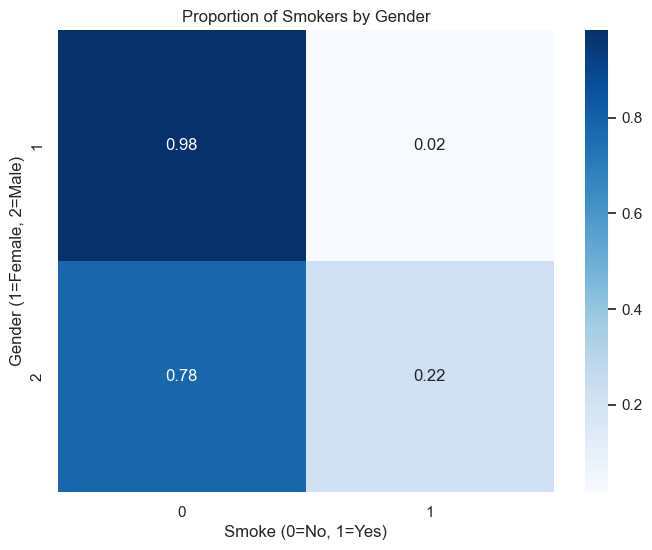

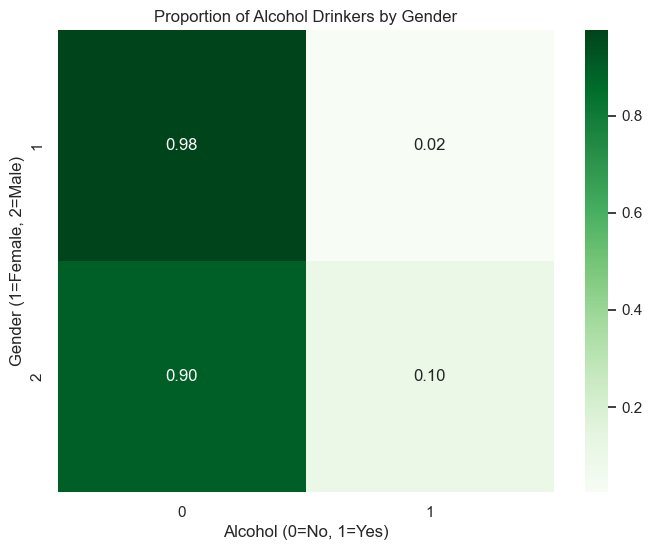

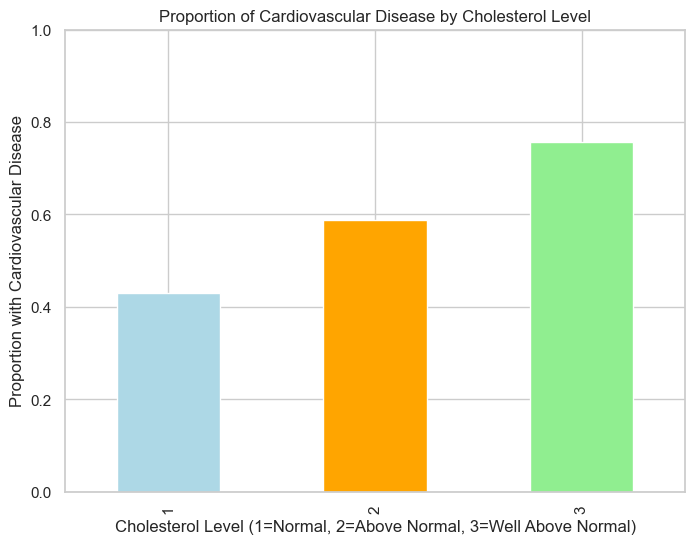

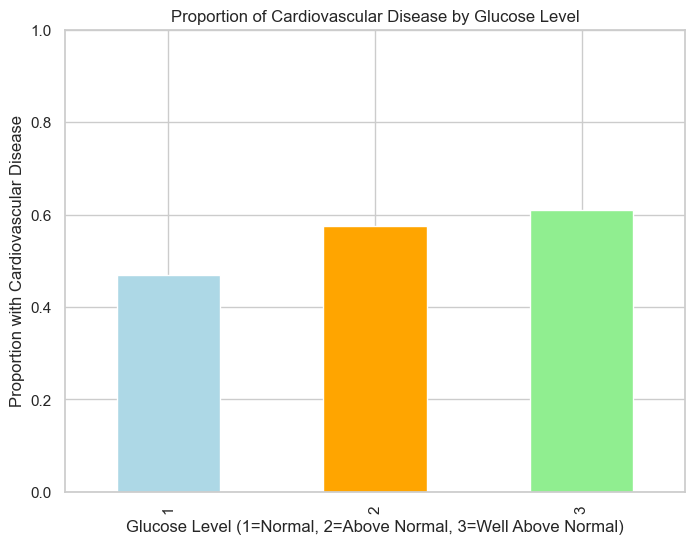

/var/folders/42/mscgv2yn64gc53f4rsg421pr0000gn/T/ipykernel_64850/2385455259.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_cardio_rate = df.groupby('bmi_bin')['cardio'].mean().reset_index()


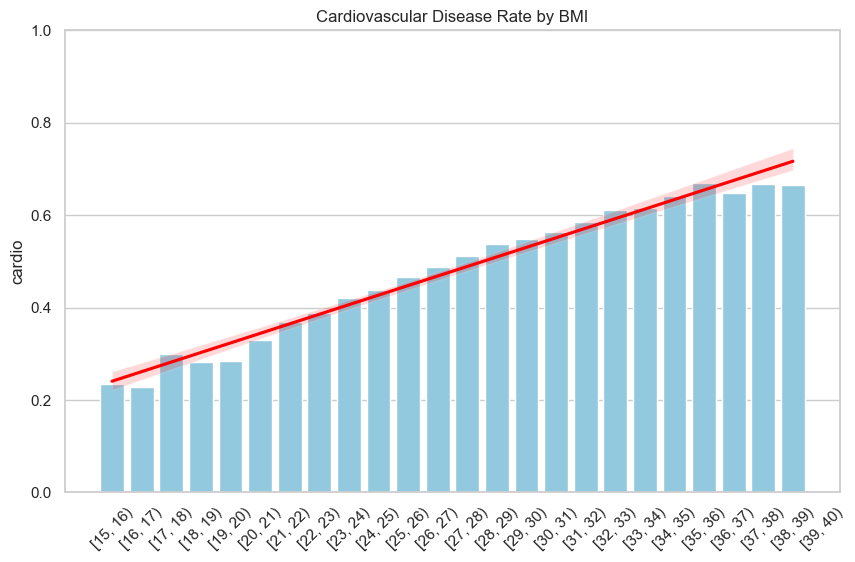

/var/folders/42/mscgv2yn64gc53f4rsg421pr0000gn/T/ipykernel_64850/2385455259.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ap_lo_cardio_rate = df.groupby('ap_lo_bin')['cardio'].mean().reset_index()


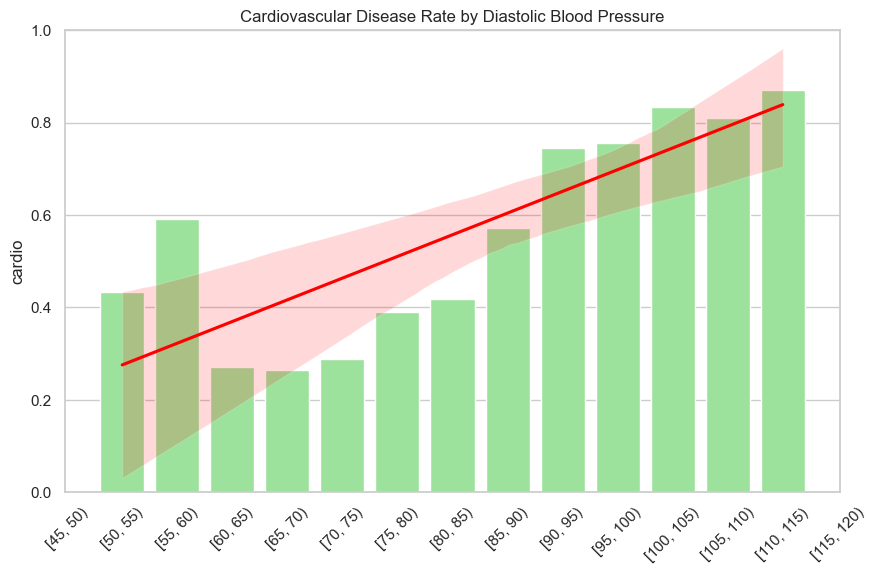

/var/folders/42/mscgv2yn64gc53f4rsg421pr0000gn/T/ipykernel_64850/2385455259.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ap_hi_cardio_rate = df.groupby('ap_hi_bin')['cardio'].mean().reset_index()


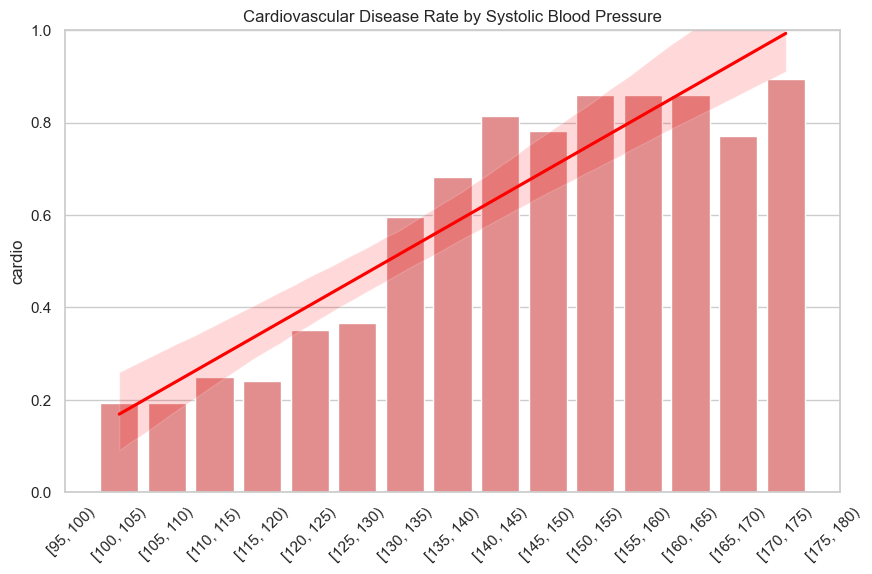

/var/folders/42/mscgv2yn64gc53f4rsg421pr0000gn/T/ipykernel_64850/2385455259.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cardio_rate = df.groupby('age_bin')['cardio'].mean().reset_index()


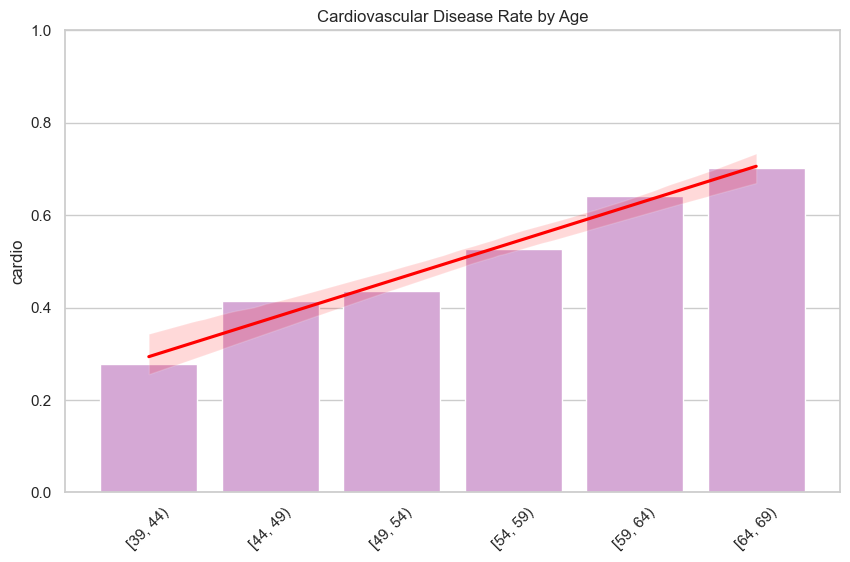

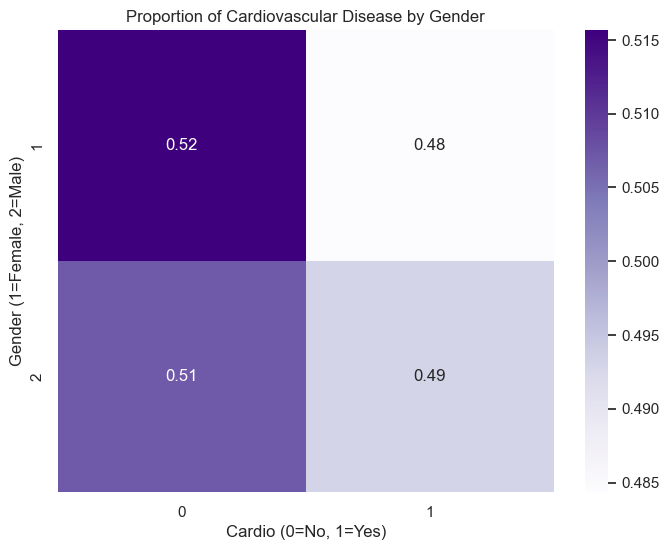

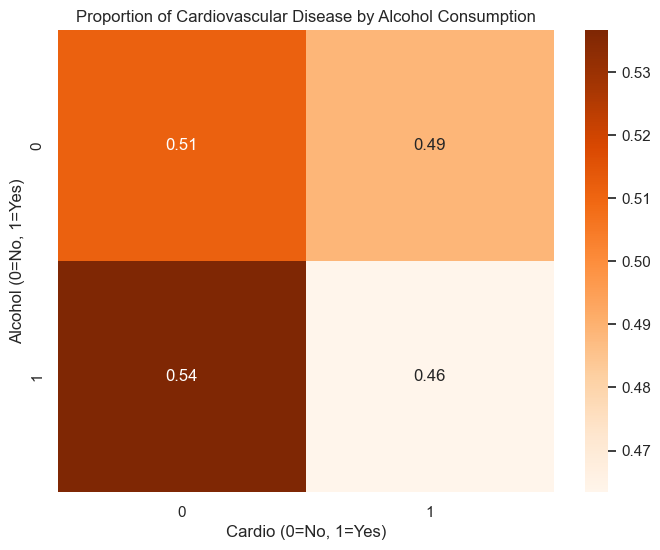

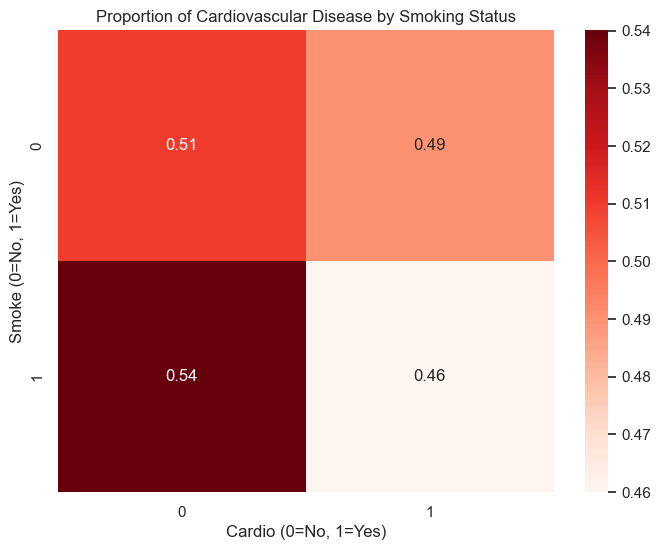

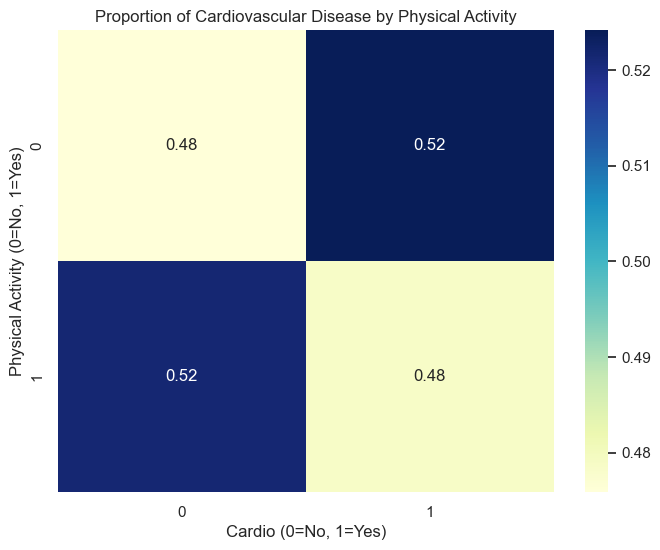

In [40]:
# 男性/女性 vs 抽烟/不抽烟 热力图
plt.figure(figsize=(8, 6))
smoking_pivot = smoking_table.div(smoking_table.sum(axis=1), axis=0)
sns.heatmap(smoking_pivot, annot=True, fmt=".2f", cmap='Blues')
plt.title('Proportion of Smokers by Gender')
plt.xlabel('Smoke (0=No, 1=Yes)')
plt.ylabel('Gender (1=Female, 2=Male)')
plt.savefig(OUT_DIR / 'gender_smoking_heatmap.png')
plt.show()

# 男性/女性 vs 饮酒/不饮酒 热力图
plt.figure(figsize=(8, 6))
alcohol_pivot = alcohol_table.div(alcohol_table.sum(axis=1), axis=0)
sns.heatmap(alcohol_pivot, annot=True, fmt=".2f", cmap='Greens')
plt.title('Proportion of Alcohol Drinkers by Gender')
plt.xlabel('Alcohol (0=No, 1=Yes)')
plt.ylabel('Gender (1=Female, 2=Male)')
plt.savefig(OUT_DIR / 'gender_alcohol_heatmap.png')
plt.show()

# 胆固醇与心血管疾病的关系柱状图，只显示Yes比例
chol_cardio = pd.crosstab(df['cholesterol'], df['cardio'], normalize='index')
plt.figure(figsize=(8, 6))
chol_cardio[1].plot(kind='bar', color=['lightblue', 'orange', 'lightgreen'])
plt.title('Proportion of Cardiovascular Disease by Cholesterol Level')
plt.xlabel('Cholesterol Level (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.ylabel('Proportion with Cardiovascular Disease')
plt.ylim(0, 1)
plt.savefig(OUT_DIR / 'cholesterol_cardio_barplot.png')
plt.show()

# 血糖与心血管疾病的关系柱状图，只显示Yes比例
gluc_cardio = pd.crosstab(df['gluc'], df['cardio'], normalize='index')
plt.figure(figsize=(8, 6))
gluc_cardio[1].plot(kind='bar', color=['lightblue', 'orange', 'lightgreen'])
plt.title('Proportion of Cardiovascular Disease by Glucose Level')
plt.xlabel('Glucose Level (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.ylabel('Proportion with Cardiovascular Disease')
plt.ylim(0, 1)
plt.savefig(OUT_DIR / 'glucose_cardio_barplot.png')
plt.show()

# BMI以1.0为间隔的患病率直方图，只要患病率。BMI从15-40。带上一个best linear fit line。不要忘记直方图。
bmi_bins = np.arange(15, 41, 1)
df['bmi_bin'] = pd.cut(df['bmi'], bins=bmi_bins, right=False)
bmi_cardio_rate = df.groupby('bmi_bin')['cardio'].mean().reset_index() 
plt.figure(figsize=(10, 6))
sns.barplot(x='bmi_bin', y='cardio', data=bmi_cardio_rate, color='skyblue')
z = np.polyfit(bmi_cardio_rate.index, bmi_cardio_rate['cardio'], 1)
p = np.poly1d(z)
plt.plot(bmi_cardio_rate.index, p(bmi_cardio_rate.index), "r--")
plt.title('Cardiovascular Disease Rate by BMI')
plt.xlabel('BMI Bins')
plt.ylabel('Cardiovascular Disease Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)
# 加线性回归线上去
sns.regplot(x=bmi_cardio_rate.index, y=bmi_cardio_rate['cardio'], scatter=False, color='red')
plt.savefig(OUT_DIR / 'bmi_cardio_rate_histogram.png')
plt.show()

# 舒张压以5为间隔的患病率直方图，只要患病率。带上一个best linear fit line。不要忘记直方图。
ap_lo_bins = np.arange(40, 155, 5)
df['ap_lo_bin'] = pd.cut(df['ap_lo'], bins=ap_lo_bins, right=False)
ap_lo_cardio_rate = df.groupby('ap_lo_bin')['cardio'].mean().reset_index() 
plt.figure(figsize=(10, 6))
sns.barplot(x='ap_lo_bin', y='cardio', data=ap_lo_cardio_rate, color='lightgreen')
z = np.polyfit(ap_lo_cardio_rate.index, ap_lo_cardio_rate['cardio'], 1)
p = np.poly1d(z)
plt.plot(ap_lo_cardio_rate.index, p(ap_lo_cardio_rate.index), "r--")
plt.title('Cardiovascular Disease Rate by Diastolic Blood Pressure')
plt.xlabel('Diastolic Blood Pressure Bins')
plt.ylabel('Cardiovascular Disease Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)
# 加线性回归线上去
sns.regplot(x=ap_lo_cardio_rate.index, y=ap_lo_cardio_rate['cardio'], scatter=False, color='red')
plt.savefig(OUT_DIR / 'ap_lo_cardio_rate_histogram.png')
plt.show()

# 收缩压以5为间隔的患病率直方图，只要患病率。带上一个best linear fit line。不要忘记直方图。
ap_hi_bins = np.arange(70, 255, 5)
df['ap_hi_bin'] = pd.cut(df['ap_hi'], bins=ap_hi_bins, right=False)
ap_hi_cardio_rate = df.groupby('ap_hi_bin')['cardio'].mean().reset_index() 
plt.figure(figsize=(10, 6))
sns.barplot(x='ap_hi_bin', y='cardio', data=ap_hi_cardio_rate, color='lightcoral')
z = np.polyfit(ap_hi_cardio_rate.index, ap_hi_cardio_rate['cardio'], 1)
p = np.poly1d(z)
plt.plot(ap_hi_cardio_rate.index, p(ap_hi_cardio_rate.index), "r--")
plt.title('Cardiovascular Disease Rate by Systolic Blood Pressure')
plt.xlabel('Systolic Blood Pressure Bins')
plt.ylabel('Cardiovascular Disease Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)
# 加线性回归线上去
sns.regplot(x=ap_hi_cardio_rate.index, y=ap_hi_cardio_rate['cardio'], scatter=False, color='red')
plt.savefig(OUT_DIR / 'ap_hi_cardio_rate_histogram.png')
plt.show()

# 年龄以5为间隔的患病率直方图，只要患病率。带上一个best linear fit line。不要忘记直方图。39开始。
age_bins = np.arange(39, 81, 5)
df['age_bin'] = pd.cut(df['age_years'], bins=age_bins, right=False)
age_cardio_rate = df.groupby('age_bin')['cardio'].mean().reset_index() 
plt.figure(figsize=(10, 6))
sns.barplot(x='age_bin', y='cardio', data=age_cardio_rate, color='plum')
z = np.polyfit(age_cardio_rate.index, age_cardio_rate['cardio'], 1)
p = np.poly1d(z)
plt.plot(age_cardio_rate.index, p(age_cardio_rate.index), "r--")
plt.title('Cardiovascular Disease Rate by Age')
plt.xlabel('Age Bins')
plt.ylabel('Cardiovascular Disease Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)
# 加线性回归线上去
sns.regplot(x=age_cardio_rate.index, y=age_cardio_rate['cardio'], scatter=False, color='red')
plt.savefig(OUT_DIR / 'age_cardio_rate_histogram.png')
plt.show()

# 性别和心血管疾病的热力图，不要写All栏目，不要用之前的contingency_table变量，重新生成一个新的变量。
plt.figure(figsize=(8, 6))
gender_cardio_pivot = pd.crosstab(df['gender'], df['cardio'], normalize='index')
sns.heatmap(gender_cardio_pivot, annot=True, fmt=".2f", cmap='Purples')
plt.title('Proportion of Cardiovascular Disease by Gender')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Gender (1=Female, 2=Male)')
plt.savefig(OUT_DIR / 'gender_cardio_heatmap.png')
plt.show()

# 是否抽烟和心血管疾病的热力图
plt.figure(figsize=(8, 6))
alco_cardio_pivot = alco_cardio_table.div(alco_cardio_table.sum(axis=1), axis=0)
sns.heatmap(alco_cardio_pivot, annot=True, fmt=".2f", cmap='Oranges')
plt.title('Proportion of Cardiovascular Disease by Alcohol Consumption')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Alcohol (0=No, 1=Yes)')
plt.savefig(OUT_DIR / 'alcohol_cardio_heatmap.png')
plt.show()

# 是否饮酒和心血管疾病的热力图
plt.figure(figsize=(8, 6))
smoke_cardio_pivot = cardio_table.div(cardio_table.sum(axis=1), axis=0)
sns.heatmap(smoke_cardio_pivot, annot=True, fmt=".2f", cmap='Reds')
plt.title('Proportion of Cardiovascular Disease by Smoking Status')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Smoke (0=No, 1=Yes)')
plt.savefig(OUT_DIR / 'smoking_cardio_heatmap.png')
plt.show()

# 是否运动与心血管疾病的热力图
exercise_cardio_table = pd.crosstab(df['active'], df['cardio'])
plt.figure(figsize=(8, 6))
exercise_cardio_pivot = exercise_cardio_table.div(exercise_cardio_table.sum(axis=1), axis=0)
sns.heatmap(exercise_cardio_pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Proportion of Cardiovascular Disease by Physical Activity')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Physical Activity (0=No, 1=Yes)')
plt.savefig(OUT_DIR / 'exercise_cardio_heatmap.png')
plt.show()